In [20]:
import pandas as pd
import seaborn as sn

In [21]:
df = pd.read_csv("heights.csv")
df.head()

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


In [22]:
df.height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: height, dtype: float64

<Axes: xlabel='height', ylabel='Count'>

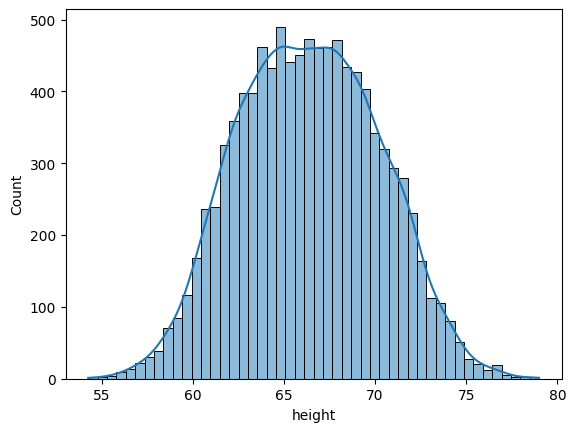

In [23]:
sn.histplot(df.height, kde=True)

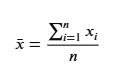

In [24]:
mean = df.height.mean()
mean

np.float64(66.367559754866)

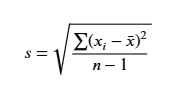

In [25]:
std_deviation = df.height.std()
std_deviation

np.float64(3.847528120795573)

In [26]:
mean-3*std_deviation

np.float64(54.824975392479274)

In [27]:
mean+3*std_deviation

np.float64(77.91014411725271)

In [28]:
df[(df.height < 54.82) | (df.height > 77.91)]

,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [29]:
df_no_outlier = df[(df.height<77.91) & (df.height>54.82)]
df_no_outlier.shape

(9993, 2)

In [30]:
df_no_outlier.head()

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


<Axes: xlabel='height', ylabel='Count'>

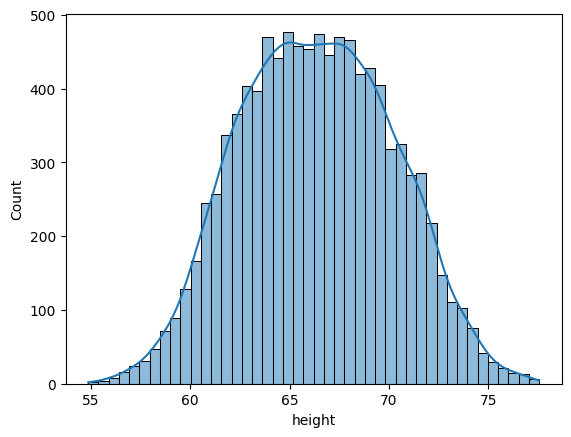

In [31]:
sn.histplot(df_no_outlier.height, kde=True)

(2) Outlier detection and removal using Z Score

Z score is a way to achieve same thing that we did above in part (1)

Z score indicates how many standard deviation away a data point is.

For example in our case mean is 66.37 and standard deviation is 3.84.

If a value of a data point is 77.91 then Z score for that is 3 because it is 3 standard deviation away (77.91 = 66.37 + 3 * 3.84)

Calculate the Z Score

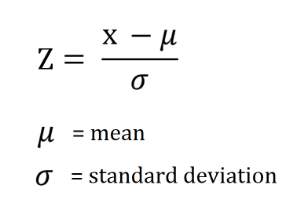

In [32]:
df['zscore'] = ( df.height - df.height.mean() ) / df.height.std()
df.head(5)

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [33]:
df.height.mean()

np.float64(66.367559754866)

In [34]:
df.height.std()

np.float64(3.847528120795573)

In [35]:
(73.84-66.37)/3.84

1.9453124999999998

In [36]:
df[df['zscore']>3]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [37]:
df[df['zscore']<-3]

,gender,height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [38]:
df_no_outlier = df[(df['zscore'] < 3) & (df['zscore'] > -3)]
df_no_outlier

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375
...,...,...,...
9995,Female,66.172652,-0.050658
9996,Female,67.067155,0.181830
9997,Female,63.867992,-0.649655
9998,Female,69.034243,0.693090


<Axes: xlabel='height', ylabel='Count'>

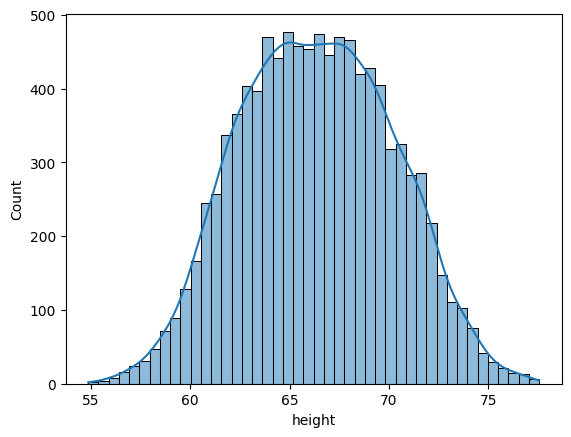

In [40]:
sn.histplot(df_no_outlier.height, kde=True)